# 🌾 Crop Recommendation Model Training

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
print('Libraries loaded!')

Libraries loaded!


In [2]:
df = pd.read_csv('../datasets/Crop_recommendation.csv')
print(f'Shape: {df.shape}')
df.head(5)

Shape: (7700, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
# Perform data augmentation for each class by generating synthetic data within wider realistic ranges.
np.random.seed(42)

augmented_dfs = [df.copy()]

# Broaden ranges for augmentation per crop based on realistic inputs and the dataset
crop_augmentations = {
    "rice": {
        "rainfall": (150, 300),
        "temperature": (20, 28),
        "humidity": (75, 85)
    },
    "maize": {
        "K": (15, 45),
        "temperature": (18, 30),
        "rainfall": (60, 130),
        "humidity": (55, 75)
    },
    "cotton": {
        "temperature": (20, 32),
        "humidity": (55, 85),
        "rainfall": (60, 100)
    },
    "chickpea": {
        "temperature": (15, 25),
        "humidity": (10, 60),
        "K": (70, 85)
    },
    "coffee": {
        "rainfall": (100, 2000),
        "humidity": (50, 90),
        "temperature": (20, 28)
    },
    "banana": {
        "rainfall": (90, 350),
        "humidity": (75, 90)
    },
    "mango": {
        "rainfall": (80, 200),
        "temperature": (27, 33),
        "humidity": (45, 60)
    },
    "coconut": {
        "rainfall": (130, 300),
        "humidity": (85, 95)
    },
    "orange": {
        "humidity": (70, 95),
        "temperature": (10, 35)
    },
    "watermelon": {
        "humidity": (65, 90),
        "temperature": (24, 32)
    }
}

feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
for crop, aug in crop_augmentations.items():
    crop_df = df[df['label'] == crop]
    n_synthetic = 250
    synthetic_data = {}
    for col in feature_cols:
        if col in aug:
            low, high = aug[col]
            synthetic_data[col] = np.random.uniform(low, high, n_synthetic)
        else:
            mean = crop_df[col].mean()
            std = crop_df[col].std() if crop_df[col].std() > 0 else 1.0
            synthetic_data[col] = np.random.normal(mean, std, n_synthetic)
    synthetic_data['label'] = [crop] * n_synthetic
    augmented_dfs.append(pd.DataFrame(synthetic_data))

aug_df = pd.concat(augmented_dfs, ignore_index=True)
print(f"Original shape: {df.shape}, Augmented shape: {aug_df.shape}")

X = aug_df[feature_cols].values
y = aug_df['label'].values

le_crop = LabelEncoder()
y_encoded = le_crop.fit_transform(y)
print(f'Features shape: {X.shape}, unique crops: {len(le_crop.classes_)}')

Original shape: (7700, 8), Augmented shape: (10200, 8)
Features shape: (10200, 7), unique crops: 22


In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2', None]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_grid, cv=3)
rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_

print(f"Best parameters: {rf_grid.best_params_}")
print(f'Train Accuracy: {accuracy_score(y_train, rf_model.predict(X_train)):.4f}')
print(f'Test Accuracy:  {accuracy_score(y_test, rf_model.predict(X_test)):.4f}')

Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Train Accuracy: 0.9977


Test Accuracy:  0.9926


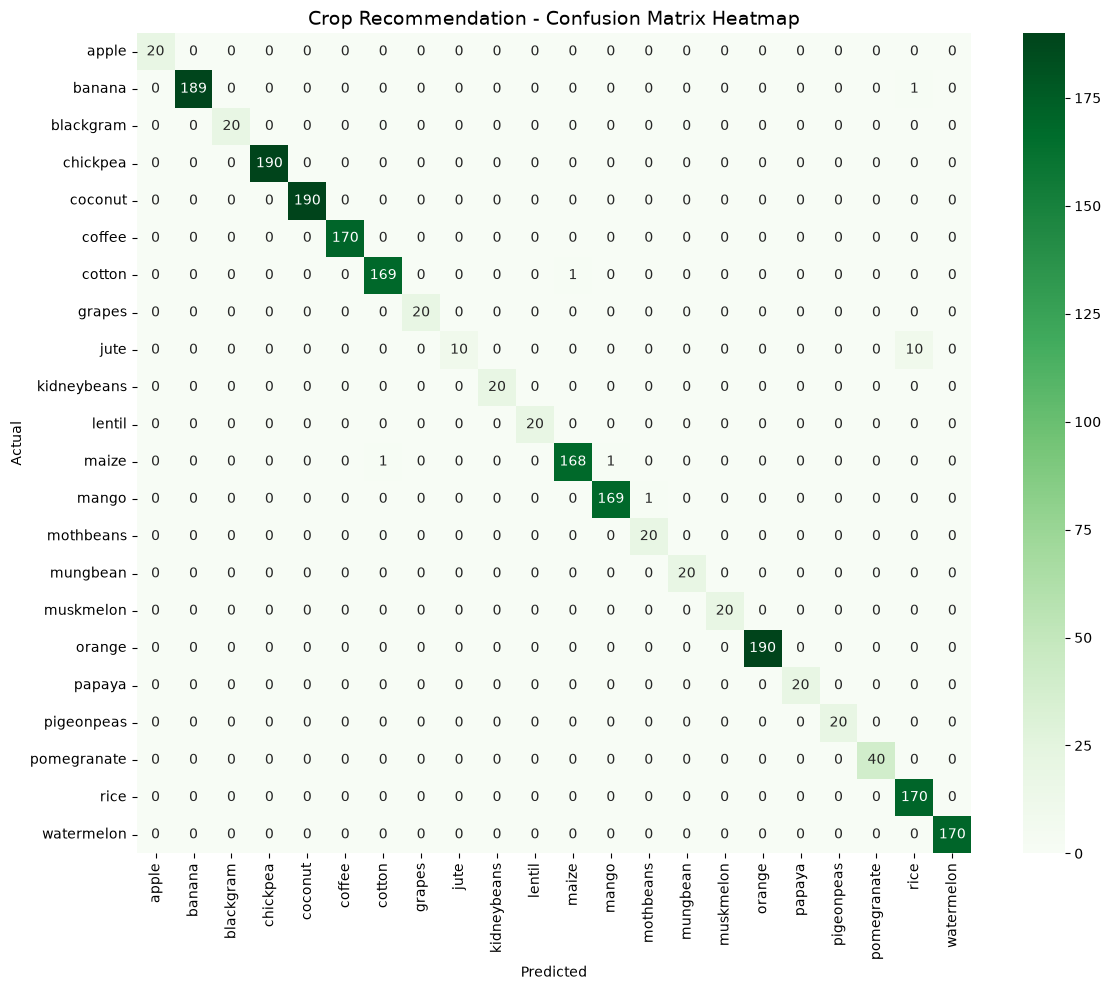

CROP CLASSIFICATION REPORT
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      0.99      1.00       190
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00       190
     coconut       1.00      1.00      1.00       190
      coffee       1.00      1.00      1.00       170
      cotton       0.99      0.99      0.99       170
      grapes       1.00      1.00      1.00        20
        jute       1.00      0.50      0.67        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.99      0.99      0.99       170
       mango       0.99      0.99      0.99       170
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00       190


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, rf_model.predict(X_test))
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le_crop.classes_, yticklabels=le_crop.classes_)
plt.title('Crop Recommendation - Confusion Matrix Heatmap', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('crop_confusion_matrix.png', dpi=150)
plt.show()

print("="*60)
print("CROP CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, rf_model.predict(X_test), target_names=le_crop.classes_))

In [6]:
os.makedirs('../../ml_models', exist_ok=True)
with open('../../ml_models/crop_recommendation.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open('../../ml_models/crop_label_encoder.pkl', 'wb') as f:
    pickle.dump(le_crop, f)
print('Successfully saved crop recommendation model and encoder!')

Successfully saved crop recommendation model and encoder!
